## Importing required libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose

ImportError: cannot import name 'seasonal_decompose' from 'statsmodels.graphics.tsaplots' (c:\Users\VISHNU\anaconda3\Lib\site-packages\statsmodels\graphics\tsaplots.py)

## Loading the dataset

In [3]:
data_2022 = pd.read_excel("supply_chain_data.xlsx", sheet_name = 'Demand_2022', header=1, usecols = "A:G")
data_2022 = data_2022[data_2022["Date"].astype(str).str.match(r"\d{4}-\d{2}-\d{2}")].copy()
data_2023 = pd.read_excel("supply_chain_data.xlsx", sheet_name = 'Demand_2023', header=1, usecols = "A:G")
data_2023 = data_2023[data_2023["Date"].astype(str).str.match(r"\d{4}-\d{2}-\d{2}")].copy()
data_2024 = pd.read_excel("supply_chain_data.xlsx", sheet_name = 'Demand_2024', header=1, usecols = "A:G")
data_2024 = data_2024[data_2024["Date"].astype(str).str.match(r"\d{4}-\d{2}-\d{2}")].copy()

data = pd.concat([data_2022, data_2023, data_2024], ignore_index=True)
data = data[["Date", "Daily Demand (Units)"]]
data["Date"] = pd.to_datetime(data["Date"])
data["Daily Demand (Units)"] = pd.to_numeric(data["Daily Demand (Units)"], errors='coerce')

In [4]:
data.head()

,Date,Daily Demand (Units)
0,2022-01-01,138
1,2022-01-02,129
2,2022-01-03,171
3,2022-01-04,184
4,2022-01-05,158


## Exploratory data analysis

In [21]:
def mean_std_analysis(data, column_name):
    mean_demand = data[column_name].mean()
    std_demand = data[column_name].std()
    
    print(f"Mean Daily Demand: {mean_demand:.2f} units")
    print(f"Standard Deviation of Daily Demand: {std_demand:.2f} units")

In [22]:
def histogram_analysis(data, column_name):
    data[column_name].hist(bins = 50, edgecolor='black', grid = False)
    plt.title(f'Distribution of {column_name}')
    plt.xlabel(column_name)
    plt.ylabel('Frequency')
    plt.show()

In [23]:
def qq_plot_analysis(data, column_name):
    stats.probplot(data[column_name], dist="norm", plot=plt)
    plt.title(f'Q-Q Plot of {column_name}')
    plt.show()

In [24]:
def shapiro_wilk_test(data, column_name):
    stat, p_value = stats.shapiro(data[column_name].dropna())
    print(f"Shapiro-Wilk Test Statistic: {stat:.4f}")
    print(f"Shapiro-Wilk Test p-value: {p_value:.4f}") 

    alpha = 0.05
    if p_value > alpha:
        print("Fail to reject the null hypothesis: Data is normally distributed.")
    else:
        print("Reject the null hypothesis: Data is not normally distributed.")

Mean Daily Demand: 222.29 units
Standard Deviation of Daily Demand: 36.08 units


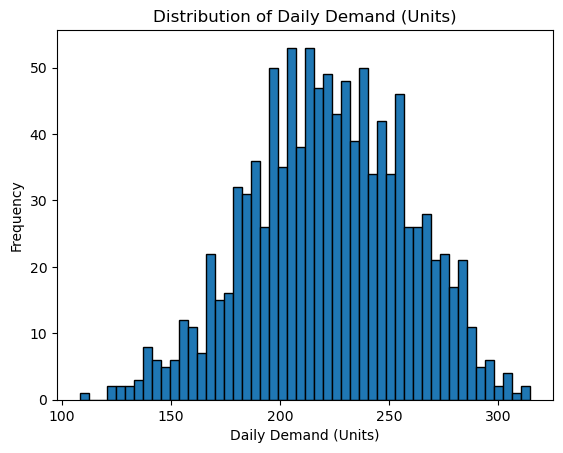

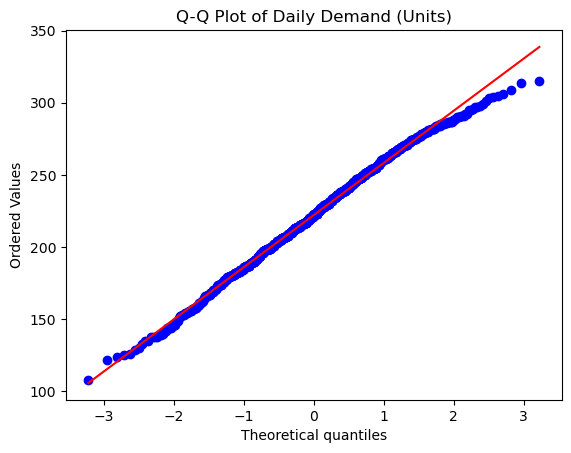

Shapiro-Wilk Test Statistic: 0.9960
Shapiro-Wilk Test p-value: 0.0065
Reject the null hypothesis: Data is not normally distributed.


In [ ]:
column_name1 = 'Daily Demand (Units)'
mean_std_analysis(data, column_name1)
histogram_analysis(data, column_name1)
qq_plot_analysis(data, column_name1)
shapiro_wilk_test(data, column_name1)

#### Performing Transformation to make the data normal

In [26]:
data['sqrt_demand'] = data['Daily Demand (Units)'].apply(lambda x: x**0.5 if x >= 0 else None) 

Mean Daily Demand: 14.86 units
Standard Deviation of Daily Demand: 1.23 units


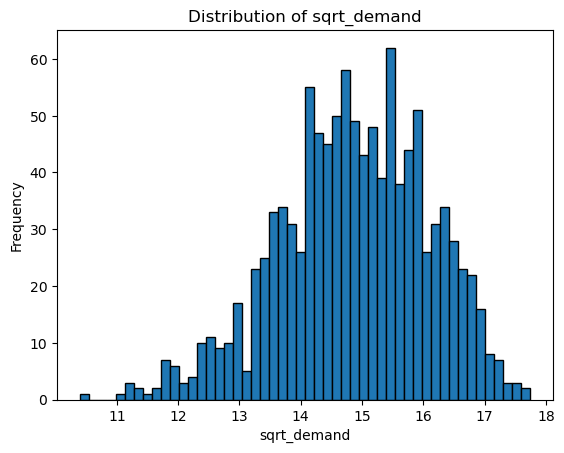

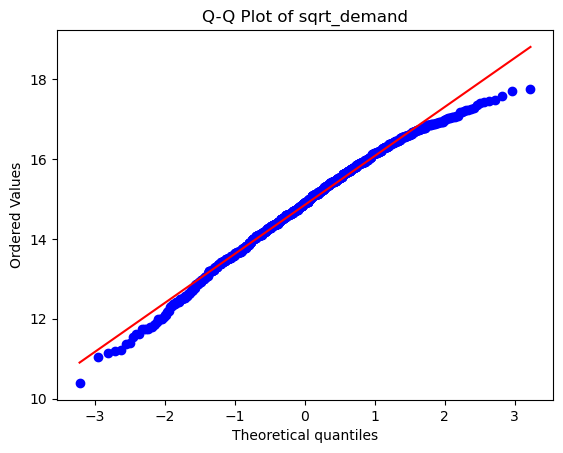

Shapiro-Wilk Test Statistic: 0.9900
Shapiro-Wilk Test p-value: 0.0000
Reject the null hypothesis: Data is not normally distributed.


In [27]:
column_name2 = 'sqrt_demand' 
mean_std_analysis(data, column_name2)
histogram_analysis(data, column_name2)
qq_plot_analysis(data, column_name2)
shapiro_wilk_test(data, column_name2)

In [30]:
data['log_demand'] = data['Daily Demand (Units)'].apply(lambda x: np.log(x) if x > 0 else None)

Mean Daily Demand: 5.39 units
Standard Deviation of Daily Demand: 0.17 units


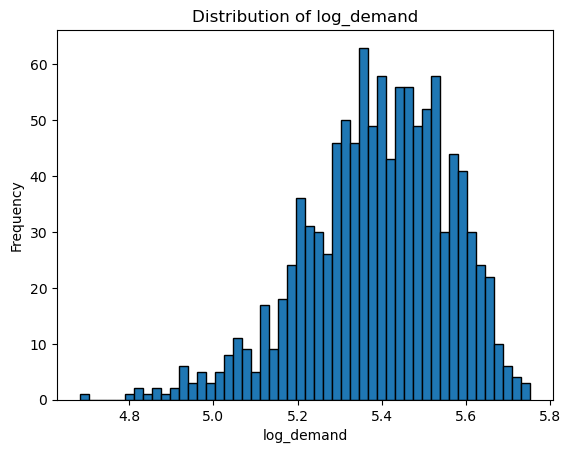

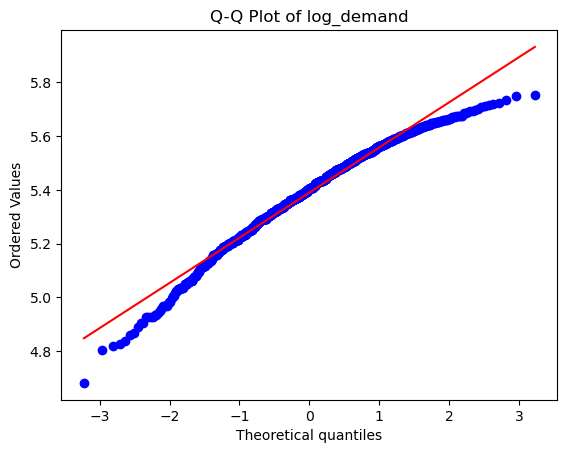

Shapiro-Wilk Test Statistic: 0.9775
Shapiro-Wilk Test p-value: 0.0000
Reject the null hypothesis: Data is not normally distributed.


In [31]:
column_name3 = 'log_demand'
mean_std_analysis(data, column_name3)
histogram_analysis(data, column_name3)
qq_plot_analysis(data, column_name3)
shapiro_wilk_test(data, column_name3)

Optimal Box-Cox Lambda: 1.2620
Mean Daily Demand: 728.17 units
Standard Deviation of Daily Demand: 147.96 units


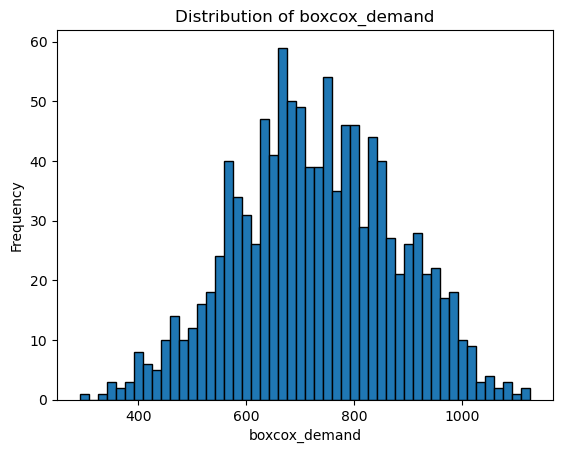

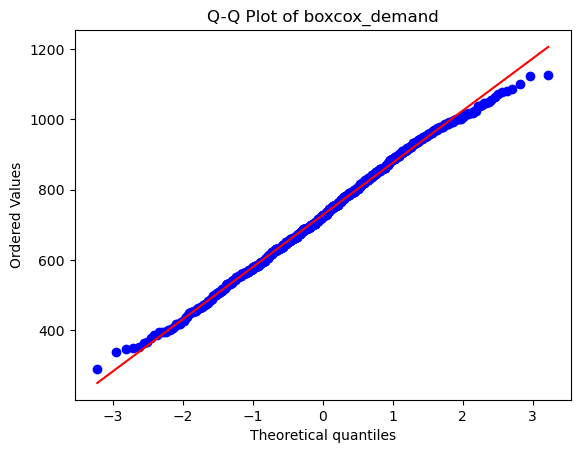

Shapiro-Wilk Test Statistic: 0.9968
Shapiro-Wilk Test p-value: 0.0268
Reject the null hypothesis: Data is not normally distributed.


In [35]:
data['boxcox_demand'], fitted_lambda = stats.boxcox(data['Daily Demand (Units)'].dropna())
print(f"Optimal Box-Cox Lambda: {fitted_lambda:.4f}")
column_name5 = 'boxcox_demand'
mean_std_analysis(data, column_name5)
histogram_analysis(data, column_name5)
qq_plot_analysis(data, column_name5)
shapiro_wilk_test(data, column_name5)

Optimal Yeo-Johnson Lambda: 1.2635
Mean Daily Demand: 737.43 units
Standard Deviation of Daily Demand: 149.35 units


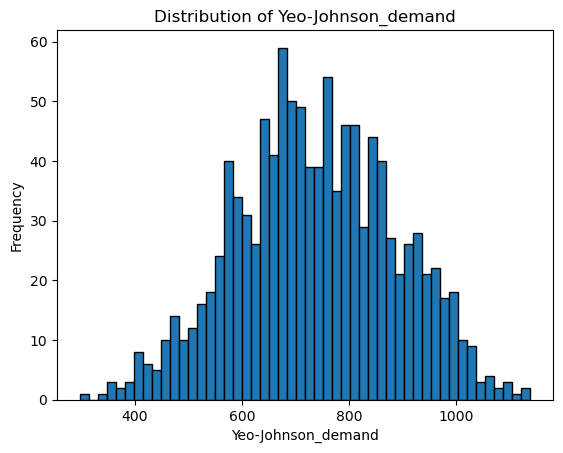

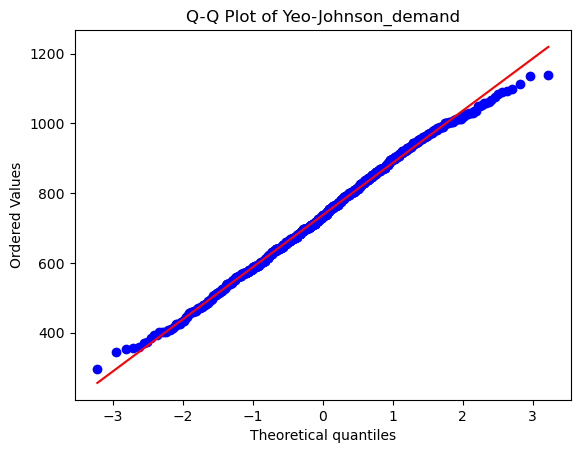

Shapiro-Wilk Test Statistic: 0.9968
Shapiro-Wilk Test p-value: 0.0269
Reject the null hypothesis: Data is not normally distributed.


In [38]:
data['Yeo-Johnson_demand'], fitted_lambda_yj = stats.yeojohnson(data['Daily Demand (Units)'].dropna())
print(f"Optimal Yeo-Johnson Lambda: {fitted_lambda_yj:.4f}")
column_name4 = 'Yeo-Johnson_demand'
mean_std_analysis(data, column_name4)
histogram_analysis(data, column_name4)
qq_plot_analysis(data, column_name4)
shapiro_wilk_test(data, column_name4)

Mean Daily Demand: 0.00 units
Standard Deviation of Daily Demand: 0.00 units


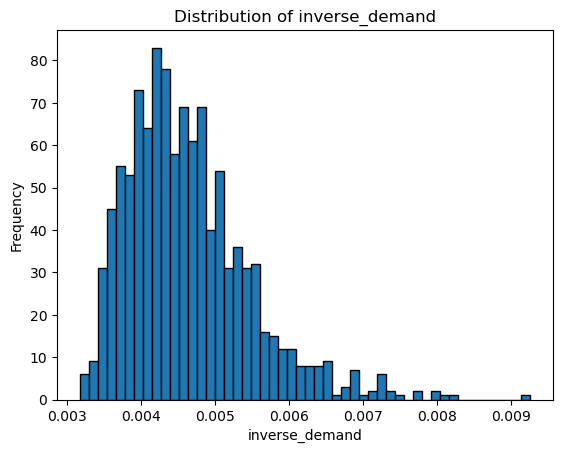

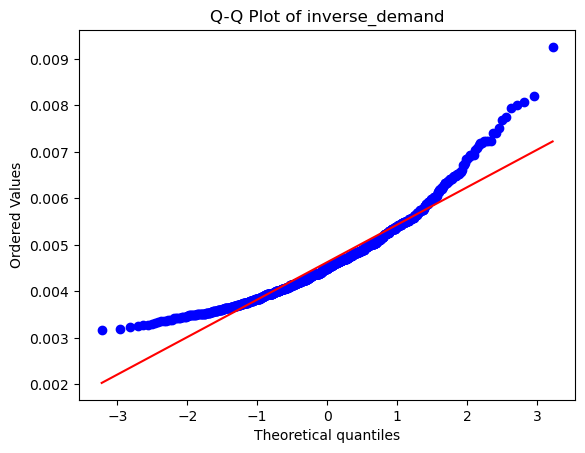

Shapiro-Wilk Test Statistic: 0.9308
Shapiro-Wilk Test p-value: 0.0000
Reject the null hypothesis: Data is not normally distributed.


In [37]:
data['inverse_demand'] = data['Daily Demand (Units)'].apply(lambda x: 1/x if x > 0 else None)
column_name6 = 'inverse_demand'
mean_std_analysis(data, column_name6)
histogram_analysis(data, column_name6)
qq_plot_analysis(data, column_name6)
shapiro_wilk_test(data, column_name6)

#### From the data, the transformation of data using Yeo-Johnson will work for us.

## Plotting the Data to check seasonality

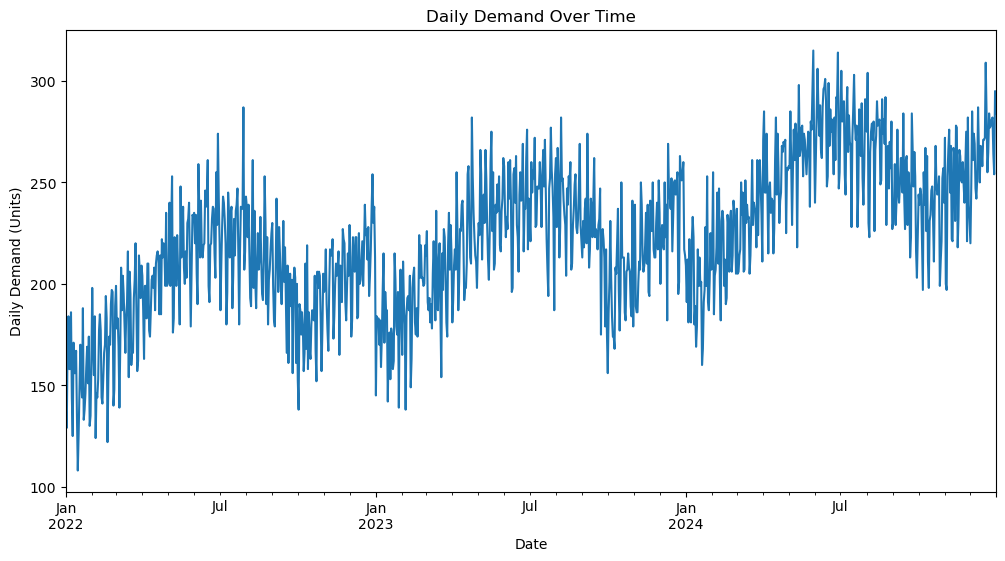

In [6]:
data.set_index('Date', inplace=True)

data['Daily Demand (Units)'].plot(figsize=(12, 6), title='Daily Demand Over Time')
plt.xlabel('Date')
plt.ylabel('Daily Demand (Units)')
plt.show()

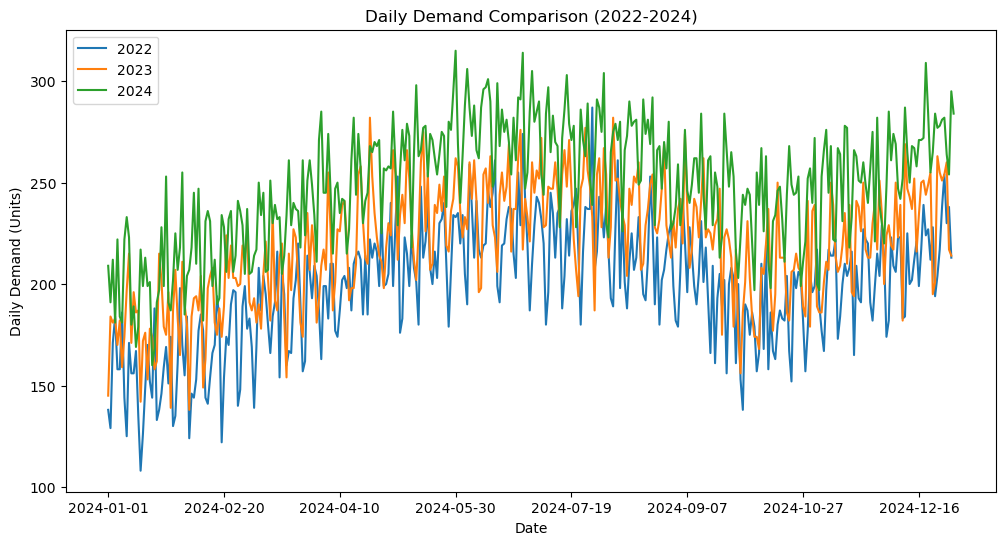

In [7]:
fig, ax = plt.subplots(figsize=(12, 6))

data_2022.set_index('Date')['Daily Demand (Units)'].plot(ax=ax, label='2022')
data_2023.set_index('Date')['Daily Demand (Units)'].plot(ax=ax, label='2023')
data_2024.set_index('Date')['Daily Demand (Units)'].plot(ax=ax, label='2024')

ax.set_title('Daily Demand Comparison (2022-2024)')
ax.set_xlabel('Date')
ax.set_ylabel('Daily Demand (Units)')
ax.legend()
plt.show()

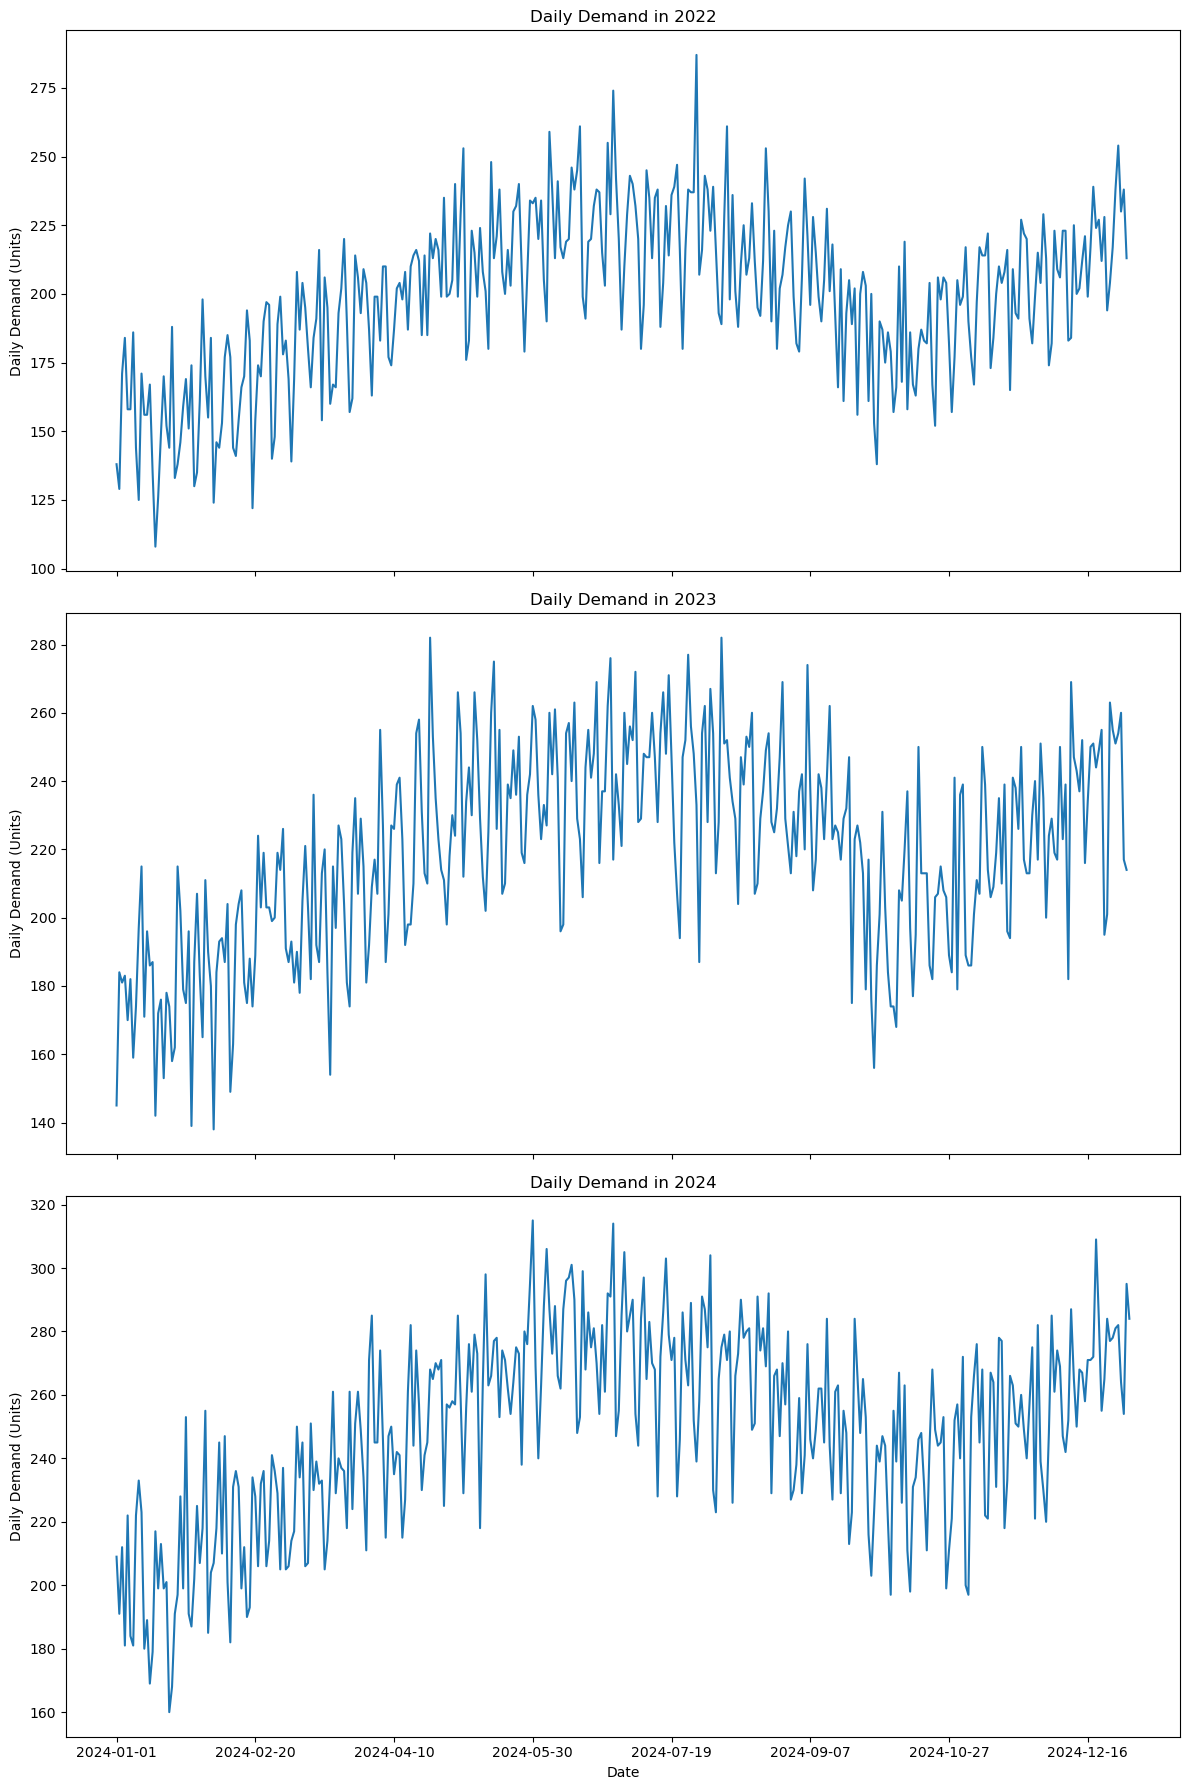

In [8]:
fig, axes = plt.subplots(nrows = 3, ncols = 1, figsize=(12, 18), sharex=True)
data_2022.set_index('Date')['Daily Demand (Units)'].plot(ax=axes[0], title='Daily Demand in 2022')
data_2023.set_index('Date')['Daily Demand (Units)'].plot(ax=axes[1], title='Daily Demand in 2023')
data_2024.set_index('Date')['Daily Demand (Units)'].plot(ax=axes[2], title='Daily Demand in 2024')
for ax in axes:
    ax.set_xlabel('Date')
    ax.set_ylabel('Daily Demand (Units)')
plt.tight_layout()
plt.show()

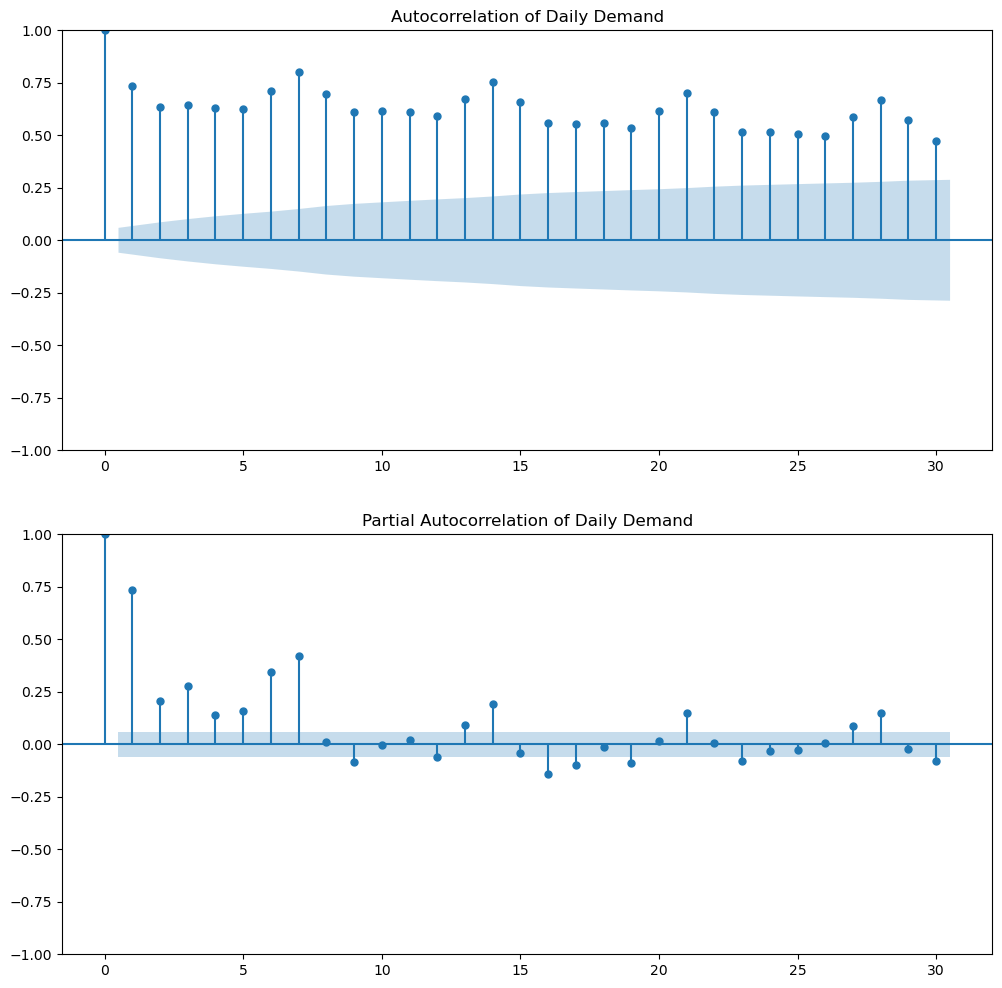

In [40]:
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(12, 12))
plot_acf(data['Daily Demand (Units)'].dropna(), ax=axes[0], lags=30)
plot_pacf(data['Daily Demand (Units)'].dropna(), ax=axes[1], lags=30)
axes[0].set_title('Autocorrelation of Daily Demand')
axes[1].set_title('Partial Autocorrelation of Daily Demand')
plt.show()